In [4]:
import pandas as pd

df = pd.read_csv('titanic.csv')
print("DATA INFO:")
print(df.info())
#to know how many column names,how mant null values, data types

DATA INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [5]:
print("SUMMARY STATISTICS:")
print(df.describe())
#show mean,min,max, etc for numeric columns

SUMMARY STATISTICS:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [7]:
print("MISSING VALUES PER COLUMN:")
print(df.isnull())

MISSING VALUES PER COLUMN:
     PassengerId  Survived  Pclass   Name    Sex    Age  SibSp  Parch  Ticket  \
0          False     False   False  False  False  False  False  False   False   
1          False     False   False  False  False  False  False  False   False   
2          False     False   False  False  False  False  False  False   False   
3          False     False   False  False  False  False  False  False   False   
4          False     False   False  False  False  False  False  False   False   
..           ...       ...     ...    ...    ...    ...    ...    ...     ...   
886        False     False   False  False  False  False  False  False   False   
887        False     False   False  False  False  False  False  False   False   
888        False     False   False  False  False   True  False  False   False   
889        False     False   False  False  False  False  False  False   False   
890        False     False   False  False  False  False  False  False   False   



In [8]:
print(df.isnull().sum())


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [10]:
#seeing what values are in embarked
print("unique values in embarked:")
print(df['Embarked'].unique())

unique values in embarked:
['S' 'C' 'Q' nan]


In [11]:
#checking the rows where embarked was missing
print('Rows with missing Embarked:')
print(df[df['Embarked'].isnull()])

Rows with missing Embarked:
     PassengerId  Survived  Pclass                                       Name  \
61            62         1       1                        Icard, Miss. Amelie   
829          830         1       1  Stone, Mrs. George Nelson (Martha Evelyn)   

        Sex   Age  SibSp  Parch  Ticket  Fare Cabin Embarked  
61   female  38.0      0      0  113572  80.0   B28      NaN  
829  female  62.0      0      0  113572  80.0   B28      NaN  


In [13]:
#seeing 2 missing values,so we can fill with the most common port
#let's find the most common port
most_common_port = df['Embarked'].mode()[0]
print(f"\nMost common port: {most_common_port}")

#fill missing Embarked values with the most common port
df['Embarked'].fillna(most_common_port, inplace=True)


Most common port: S


In [14]:
#verify no more missing values
print("\nMissing Embarked after fixing:", df['Embarked'].isnull().sum())


Missing Embarked after fixing: 0


In [17]:
#lets see age statistics 
print("Age statistics: ")
print(df['Age'].describe())

#option 1:fill with median age (better than mean because age has outliers)
median_age = df['Age'].median()
print(f"Median age: {median_age}")
df['Age'].fillna(median_age)

print("\nMissing Age after fixing:", df['Age'].isnull().sum())

Age statistics: 
count    891.000000
mean      29.361582
std       13.019697
min        0.420000
25%       22.000000
50%       28.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64
Median age: 28.0

Missing Age after fixing: 0


In [20]:
#handling cabin column
#cabin has too many missing values ,so i create a new column
#creating a cabin that says yes if cabin exists,No if missing
df['Has_Cabin'] = df['Cabin'].notnull().map({True: 'Yes', False: 'No'})
    #lets see what the new column look like
print("New Has_Cabin column:")
print(df[['Cabin', 'Has_Cabin']].head(10))   

New Has_Cabin column:
  Cabin Has_Cabin
0   NaN        No
1   C85       Yes
2   NaN        No
3  C123       Yes
4   NaN        No
5   NaN        No
6   E46       Yes
7   NaN        No
8   NaN        No
9   NaN        No


In [21]:
#check distribution
print("\nHas_Cabin distribution:")
print(df['Has_Cabin'].value_counts())


Has_Cabin distribution:
Has_Cabin
No     687
Yes    204
Name: count, dtype: int64


In [22]:
#Now we can either keep or drop it
#let's drop the original cabin column since it's mostly empty
df.drop('Cabin', axis=1, inplace=True)

print("\nColumns after dropping Cabin:")
print(df.columns.tolist())


Columns after dropping Cabin:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked', 'Has_Cabin']


In [23]:
print("current data type")
print(df.dtypes)

current data type
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Embarked        object
Has_Cabin       object
dtype: object


In [38]:
#Conerted data types to category where appropraite to save memory and enable better analysis
#fix:Convert survived to category (it should be categorical,not numerical)
df['Survived'] = df['Survived'].astype("int64")
#Fix: Convert pclass,sex,Embarkrd,Has_Cabin to category
df['Pclass'] = df['Pclass'].astype('int64')
df['Sex'] = df['Sex'].astype('category')
df['Embarked'] = df['Embarked'].astype('category')
df['Has_Cabin'] = df['Has_Cabin'].astype ('category')

#check data types after fixing
print("\nData types after fixing:")
print(df.dtypes)


Data types after fixing:
PassengerId       int64
Survived          int64
Pclass            int64
Name             object
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked       category
Has_Cabin      category
dtype: object


In [26]:
#check for duplicate 
#check if any rows are completely identical
duplicate_rows = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_rows}")

#check if any passengerId id duplicate(it should be unique)
duplicate_ids = df['PassengerId'].duplicated().sum()
print(f"Duplicate Passenger IDs: {duplicate_ids}")

Duplicate rows: 0
Duplicate Passenger IDs: 0


In [27]:
#checking the cleaned data
print(f"Data is already loaded! Shape: {df.shape}")
print(f"First row: {df.iloc[0]['Name']}")

Data is already loaded! Shape: (891, 12)
First row: Braund, Mr. Owen Harris


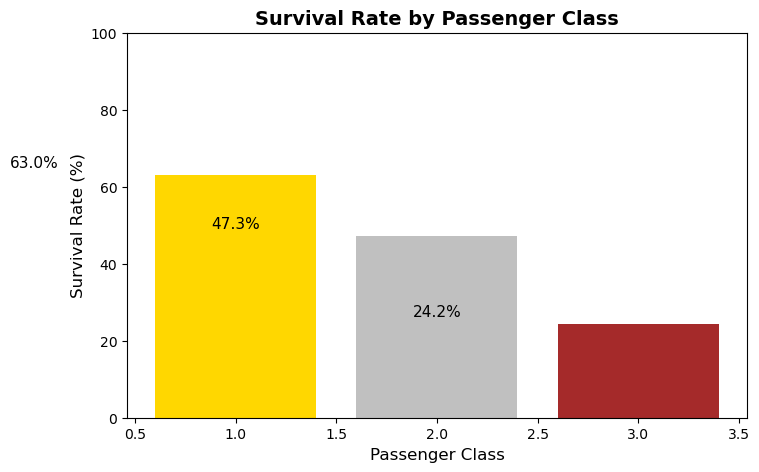

In [39]:
import matplotlib.pyplot as plt
# Visualization 1: Survival by Class
survival_by_class = df.groupby('Pclass')['Survived'].mean() * 100

plt.figure(figsize=(8, 5))
plt.bar(survival_by_class.index, survival_by_class.values, color=['gold', 'silver', 'brown'])
plt.title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
plt.xlabel('Passenger Class', fontsize=12)
plt.ylabel('Survival Rate (%)', fontsize=12)

for i, rate in enumerate(survival_by_class.values):
    plt.text(i, rate + 2, f'{rate:.1f}%', ha='center', fontsize=11)

plt.ylim(0, 100)
plt.show()

In [ ]:
#i changed the survival rate and passenger class to int64 because i could not plot the bar chart with the type as category.